# UCI Diabetes Dataset Exploration
## 0. Setup

In [45]:
# !pip3 install pandas
# !pip3 install matplotlib
# !pip3 install statsmodels

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.stats.proportion import proportion_confint

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 100)

RAW_PATH = "../data/diabetic_data.csv"

## 1. Load and get a first look

**NOTE:** This dataset encodes missing values as the literal string `"?"`, not a blank cell.

In [42]:
df = pd.read_csv(RAW_PATH, na_values="?")
print(df.shape)
df.head()

(101766, 50)


/var/folders/nh/rtg3s5_d1dgggdhrbtsykrm00000gn/T/ipykernel_5321/1546368192.py:1: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(RAW_PATH, na_values="?")


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [9]:
df.columns.tolist()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'weight',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted']

## 2. Missingness

*Where is data actually missing, and how much?*

In [10]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64

`max_glu_serum` and `A1Cresult` do not actually have missing values according to UCI. "Missing" values in these variables means the test was not taken. 

`weight` will be dropped due to being ~97% missing. `medical_specialty` will be dropped due to being ~49% missing and not being a target variable or containing information of high business value.

I'm keeping `payer_code` as it can be a proxy for real clinical/social factors that do affect readmission risk e.g. self-pay or uninsured patients may face barriers to follow-up care, medication adherence, or outpatient access, which are known readmission drivers. Medicare patients also skew older and sicker, which also correlates with readmission risk. 

## 3. The target variable

`<30` will be the positive class. `NO` and `>30` will be the negative class.

In [12]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [13]:
df["readmitted"].value_counts(normalize=True) * 100

readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64

In [14]:
df.groupby("readmitted")["time_in_hospital"].mean()

readmitted
<30    4.768249
>30    4.495541
NO     4.254429
Name: time_in_hospital, dtype: float64

`time_in_hospital` shows the number of days between admission and discharge. The length of stay does not look related to the readmission outcome.

## 4. One row per encounter, or one per patient?

Check whether any patients show up more than once.

In [15]:
n_rows = len(df)
n_unique_patients = df["patient_nbr"].nunique()
print(f"rows: {n_rows:,}   unique patients: {n_unique_patients:,}")
print(f"repeat-encounter rows: {n_rows - n_unique_patients:,}")

rows: 101,766   unique patients: 71,518
repeat-encounter rows: 30,248


In [16]:
df["patient_nbr"].value_counts().head(10)

patient_nbr
88785891    40
43140906    28
1660293     23
23199021    23
88227540    23
23643405    22
84428613    22
92709351    21
90609804    20
89472402    20
Name: count, dtype: int64

In [52]:
df.sort_values(by='encounter_id').head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
8,12522,48330783,Caucasian,Female,[80-90),NaN,2,1,4,13,NaN,NaN,68,2,28,0,0,0,398,427,38,8,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),NaN,3,3,4,12,NaN,InternalMedicine,33,3,18,0,0,0,434,198,486,8,NaN,NaN,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
10,28236,89869032,AfricanAmerican,Female,[40-50),NaN,1,1,7,9,NaN,NaN,47,2,17,0,0,0,250.7,403,996,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30
5,35754,82637451,Caucasian,Male,[50-60),NaN,2,1,2,3,NaN,NaN,31,6,16,0,0,0,414,411,250,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30


Repeat encounters will be removed. I will only be keeping the first encounter for each patient because the repeat encounter are not independent observations. I also do not want the encounters from the same patient to be split across the training and testing data.

## 5. Discharge disposition — who can't be "readmitted"?

In [18]:
df["discharge_disposition_id"].value_counts().sort_index()

discharge_disposition_id
1     60234
2      2128
3     13954
4       815
5      1184
6     12902
7       623
8       108
9        21
10        6
11     1642
12        3
13      399
14      372
15       63
16       11
17       14
18     3691
19        8
20        2
22     1993
23      412
24       48
25      989
27        5
28      139
Name: count, dtype: int64

**Questions:**
- Open `IDS_mapping.csv` (it ships alongside the main CSV) and find which `discharge_disposition_id` values correspond to death or hospice.
- How many rows in this dataset have one of those codes?
- Can a patient who died in the hospital be "readmitted"? What should happen to these rows before you build the target variable?

In [26]:
ids_map = pd.read_csv("../data/IDS_mapping.csv", header=None)

# Skips first 9 rows (admission_type)
ids_map.iloc[10:].head(31)

,0,1
10,discharge_disposition_id,description
11,1,Discharged to home
12,2,Discharged/transferred to another short term h...
13,3,Discharged/transferred to SNF
14,4,Discharged/transferred to ICF
15,5,Discharged/transferred to another type of inpa...
16,6,Discharged/transferred to home with home healt...
17,7,Left AMA
18,8,Discharged/transferred to home under care of H...
19,9,Admitted as an inpatient to this hospital


##### Excluding (anyone who died or entered hospice cannot be readmitted):
- 11 - Expired
- 13 - Hospice/home
- 14 - Hospice/medical facility
- 19 - Expired at home
- 20 - Expired in a medical facility
- 21 - Expired, place unknown

##### Excluding (data quality reasons):
- 18 - NULL
- 25 - Not mapped
- 26 - Unknown/Invalid

## 6. Categorical columns — cardinality check

High-cardinality categoricals (lots of distinct values) behave very differently from low-cardinality ones when you encode them.

In [31]:
cat_cols = df.select_dtypes(include="object").columns
cardinality = df[cat_cols].nunique().sort_values(ascending=False)
cardinality

/var/folders/nh/rtg3s5_d1dgggdhrbtsykrm00000gn/T/ipykernel_5321/812879754.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


diag_3                      789
diag_2                      748
diag_1                      716
medical_specialty            72
payer_code                   17
age                          10
weight                        9
race                          5
glipizide                     4
glyburide-metformin           4
insulin                       4
miglitol                      4
acarbose                      4
rosiglitazone                 4
pioglitazone                  4
glyburide                     4
chlorpropamide                4
nateglinide                   4
repaglinide                   4
metformin                     4
glimepiride                   4
readmitted                    3
gender                        3
tolazamide                    3
A1Cresult                     3
max_glu_serum                 3
glimepiride-pioglitazone      2
diabetesMed                   2
change                        2
metformin-pioglitazone        2
metformin-rosiglitazone       2
acetohex

## 7. Diagnosis codes

`diag_1`, `diag_2`, `diag_3` are ICD-9 codes. These will be grouped into categories to reduce the number of columns when one hot encoding.

In [32]:
df["diag_1"].value_counts().head()

diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
Name: count, dtype: int64

In [29]:
df["diag_1"].nunique(), df["diag_2"].nunique(), df["diag_3"].nunique()

(716, 748, 789)

## 8. Age

Age arrives pre-binned into 10-year buckets.

In [33]:
df["age"].value_counts().sort_index()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64

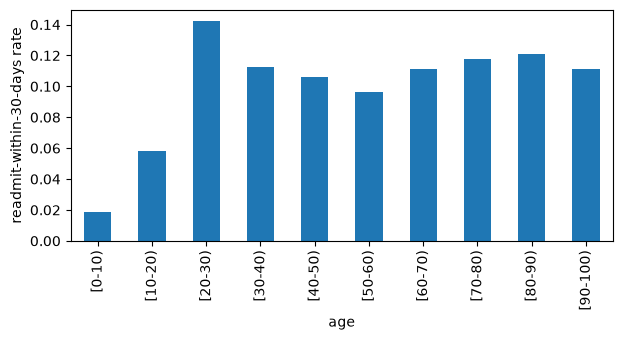

In [34]:
readmit_rate_by_age = (
    df.assign(readmitted_30d=(df["readmitted"] == "<30").astype(int))
      .groupby("age")["readmitted_30d"].mean()
)
readmit_rate_by_age.plot(kind="bar", figsize=(7, 3))
plt.ylabel("readmit-within-30-days rate")
plt.show()

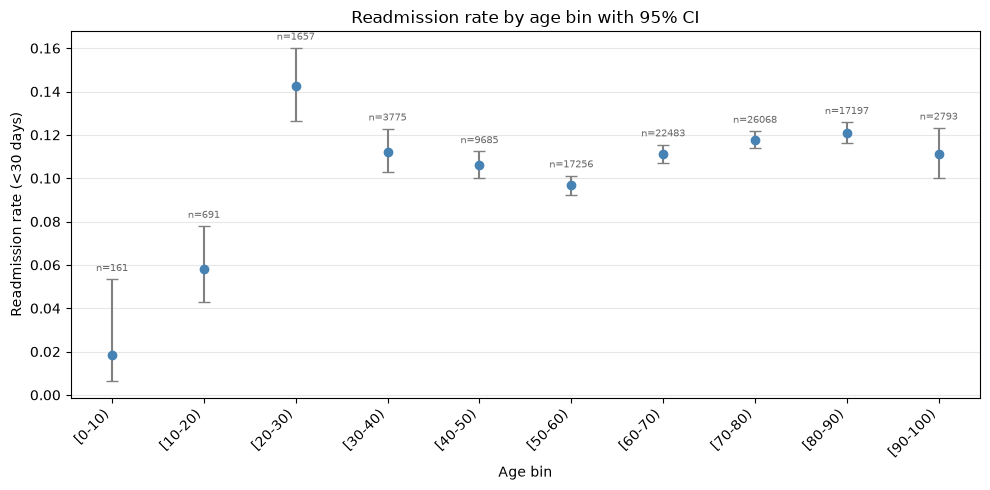

        age      n  successes      rate    ci_low    ci_upp
0    [0-10)    161          3  0.018634  0.006357  0.053346
1   [10-20)    691         40  0.057887  0.042796  0.077866
2   [20-30)   1657        236  0.142426  0.126425  0.160081
3   [30-40)   3775        424  0.112318  0.102637  0.122787
4   [40-50)   9685       1027  0.106040  0.100064  0.112329
5   [50-60)  17256       1668  0.096662  0.092342  0.101161
6   [60-70)  22483       2502  0.111284  0.107240  0.115461
7   [70-80)  26068       3069  0.117731  0.113874  0.121699
8   [80-90)  17197       2078  0.120835  0.116048  0.125791
9  [90-100)   2793        310  0.110992  0.099872  0.123180


In [40]:
df['target'] = (df['readmitted'] == '<30').astype(int)

# compute rate + CI per bin
summary = (
    df.groupby('age', observed=True)['target']
    .agg(n='count', successes='sum')
    .reset_index()
)
summary['rate'] = summary['successes'] / summary['n']

# Wilson score interval (better than normal approx for proportions)
ci_low, ci_upp = proportion_confint(
    summary['successes'], summary['n'], alpha=0.05, method='wilson'
)
summary['ci_low'] = ci_low
summary['ci_upp'] = ci_upp

# sort bins in natural age order
summary = summary.sort_values('age')

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(summary))
ax.errorbar(
    x, summary['rate'],
    yerr=[summary['rate'] - summary['ci_low'], summary['ci_upp'] - summary['rate']],
    fmt='o', capsize=4, color='steelblue', ecolor='gray', markersize=6
)

ax.set_xticks(x)
ax.set_xticklabels(summary['age'], rotation=45, ha='right')
ax.set_ylabel('Readmission rate (<30 days)')
ax.set_xlabel('Age bin')
ax.set_title('Readmission rate by age bin with 95% CI')
ax.grid(axis='y', alpha=0.3)

# annotate n per bin above each point
for xi, row in zip(x, summary.itertuples()):
    ax.annotate(f'n={row.n}', (xi, row.ci_upp), textcoords="offset points",
                xytext=(0, 6), ha='center', fontsize=7, color='dimgray')

plt.tight_layout()
plt.show()

print(summary)

Instead of the 10 distinct age bins, ages will be grouped based on the following criteria:

| Group | Bins | Rationale |
| --- | --- | --- |
| Young | 0-10, 10-20 | Distinctly lower, non-overlapping with adult range |
| Adult |20-30 | Notably higher, marginally non-overlapping |
| Mid/Senior | 30+ | CIs overlap heavily, no clear trend, safe to collapse |

## 9. The 23 medication columns

There are ~23 columns like `metformin`, `insulin`, etc., each with values like `No`, `Steady`, `Up`, `Down`.

In [44]:
med_cols = [c for c in df.columns if df[c].dtype == "str"
            and set(df[c].dropna().unique()) <= {"No", "Steady", "Up", "Down"}]
print(f"{len(med_cols)} medication columns found")
for c in med_cols:
    print(c, "->", df[c].value_counts(normalize=True).round(3).to_dict())

23 medication columns found
metformin -> {'No': 0.804, 'Steady': 0.18, 'Up': 0.01, 'Down': 0.006}
repaglinide -> {'No': 0.985, 'Steady': 0.014, 'Up': 0.001, 'Down': 0.0}
nateglinide -> {'No': 0.993, 'Steady': 0.007, 'Up': 0.0, 'Down': 0.0}
chlorpropamide -> {'No': 0.999, 'Steady': 0.001, 'Up': 0.0, 'Down': 0.0}
glimepiride -> {'No': 0.949, 'Steady': 0.046, 'Up': 0.003, 'Down': 0.002}
acetohexamide -> {'No': 1.0, 'Steady': 0.0}
glipizide -> {'No': 0.875, 'Steady': 0.112, 'Up': 0.008, 'Down': 0.006}
glyburide -> {'No': 0.895, 'Steady': 0.091, 'Up': 0.008, 'Down': 0.006}
tolbutamide -> {'No': 1.0, 'Steady': 0.0}
pioglitazone -> {'No': 0.928, 'Steady': 0.069, 'Up': 0.002, 'Down': 0.001}
rosiglitazone -> {'No': 0.937, 'Steady': 0.06, 'Up': 0.002, 'Down': 0.001}
acarbose -> {'No': 0.997, 'Steady': 0.003, 'Up': 0.0, 'Down': 0.0}
miglitol -> {'No': 1.0, 'Steady': 0.0, 'Down': 0.0, 'Up': 0.0}
troglitazone -> {'No': 1.0, 'Steady': 0.0}
tolazamide -> {'No': 1.0, 'Steady': 0.0, 'Up': 0.0}
examide 

15 out of the 23 medication columns have zero or near zero variance (almost all No). I'm going to drop these columns but before I do that I'm going to create a summary feature `num_meds_administered` that counts all the columns that are not "No".

## 10. Payer code

In [49]:
df["payer_code"].value_counts()

payer_code
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532
CP     2533
UN     2448
CM     1937
OG     1033
PO      592
DM      549
CH      146
WC      135
OT       95
MP       79
SI       55
FR        1
Name: count, dtype: int64

| Bucket | Codes | Reasoning & Social Signal|
|--------|-------|----------------|
| Medicare | MC, MP | Medicare and Medicare Primary are both federal Medicare coverage. Age-based; not primarily a disadvantage proxy |
| Medicaid | MD, DM | Medicaid and Disability Medicaid are both state/federal Medicaid programs. Means-tested; proxy for low income |
| Self-pay | SP | Uninsured — often the strongest disadvantage proxy (no coverage at all, cost-driven care avoidance) |
| Private/Commercial | HM, BC, CP, PO, CM, SI | Typically employer-sponsored — proxy for stable employment/higher income |
| Other/Government/Unknown | UN, OG, OT, CH, WC, FR | Unknown/unspecified, Other Government, Other, CHAMPUS (military), Workers' Comp, and Federal. All low-volume or ambiguous categories, better grouped together |

## 11. Numeric features — quick distribution check

In [47]:
numeric_cols = ["time_in_hospital", "num_lab_procedures", "num_procedures",
                "num_medications", "number_outpatient", "number_emergency",
                "number_inpatient", "number_diagnoses"]
df[numeric_cols].describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


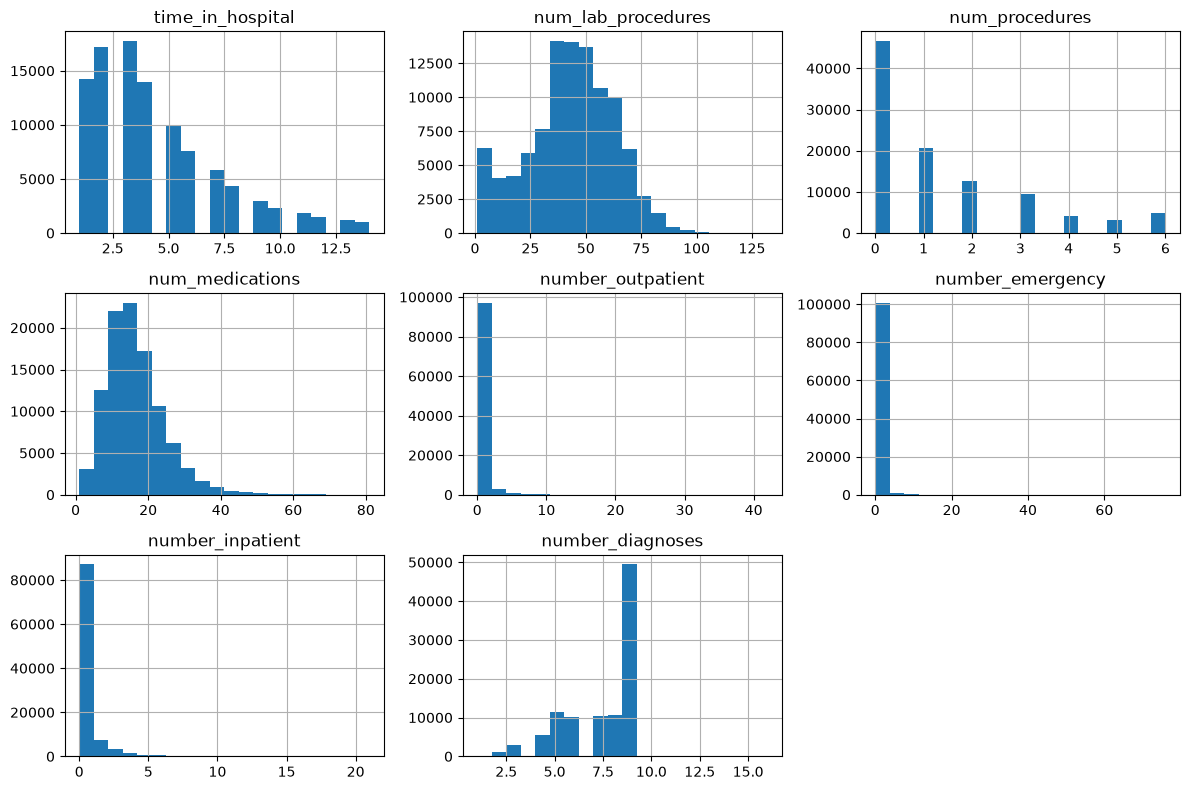

In [48]:
df[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

`number_outpatient`, `number_emergency`, and `number_inpatient` are heavily right-skewed with most patient encounters having 0 as their value. Something to consider is combining these into a "healthcare utilization" column that sums all three. Another option to consider is changing these to binary flags (any prior visits? 1, none 0). For now, since I will most likely use XGBoost, I'll leave the numeric features as is.

## 12. Preprocessing plan

Summarizing what was found during exploration and actions needed for `preprocessing.py`.

**Dropped Columns**
- `weight`
- `medical_specialty`
- `encounter_id`
- `acetohexamide`
- `tolbutamide`
- `troglitazone`
- `examide`
- `citoglipton`
- `tolazamide`
- `glipizide-metformin`
- `glimepiride-pioglitazone`
- `metformin-rosiglitazone`
- `metformin-pioglitazone`
- `acarbose`
- `chlorpropamide`
- `miglitol`
- `nateglinide`
- `glyburide-metformin`

**Excluded Rows**
- `discharge_disposition_id`: 11, 13, 14, 18, 19, 20, 21, 25, 26
  - Why? *Patient cannot be readmitted or data quality issues.*
- Only a patient's first encounter will be kept. Repeat encounters after will be removed.

**Binary Mapping `readmitted`**
- 1 (positive) = <30
- 0 (negative) = NO + >30
- Class balance is roughly 89:11 (a substantial imbalance)

**Adjustments to `age`**
- Three groups (young, adult, mid-senior)

**Adjustments to `diag_1`, `diag_2`, `diag_3`**

Each diagnosis code column will be grouped into the following categories:
1. Circulatory (390–459, 785)
2. Respiratory (460–519, 786)
3. Digestive (520–579, 787)
4. Diabetes (250.xx)
5. Injury (800–999)
6. Musculoskeletal (710–739)
7. Genitourinary (580–629, 788)
8. Neoplasms (140–239)
9. Other/remaining codes bucketed as "Other"

**Adjustments to medication columns**
- Instead of the current 4 categories (Up, Down, Steady, No), the remaining 8 medication columns will be changed to binary flags (1 if Up or Down, 0 if Steady or No).
- `num_meds_administered` will be created as a summary feature to track how many meds the patient is on for that encounter.

**Adjustments to `payer_code`**
- The 17 distinct values will be bucketed into the following categories: Medicare, Medicaid, Private, Self-pay, and Other.

**Adjustments to `change` and `diabetesMed`**
- These will be changed to binary columns:
  - `change`: No = 0, Ch = 1
  - `diabetesMed`: No = 0, Yes = 1